# GC Example 21: Tidal Radius Distribution

**EPS Research — Milky Way GC Corpus v1.3.2**

The tidal radius r_t marks where Galactic tidal forces overcome
the cluster's self-gravity. Clusters beyond r_t are stripped.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174

Clusters with r_t: 154
r_t range: 15 -- 735 pc
r_t/r_hm ratio range: 1.2 -- 70.7
Median ratio: 12.3


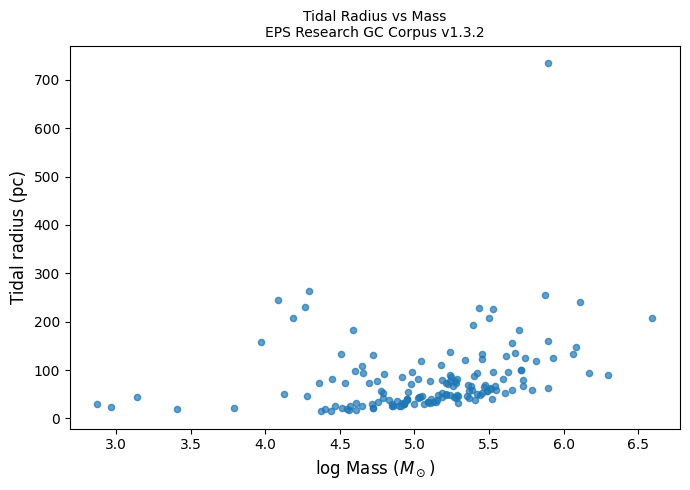

In [3]:
data=[(c['cluster_id'],c['baumgardt2023']['rt_pc'],c['baumgardt2023']['rhm_pc'],
        c['baumgardt2023']['mass_msun'])
      for c in clusters if c.get('baumgardt2023') and
      c['baumgardt2023'].get('rt_pc') and c['baumgardt2023'].get('rhm_pc')]
rt=[d[1] for d in data]; rhm=[d[2] for d in data]; mass=[d[3] for d in data]
ratio=[t/h for t,h in zip(rt,rhm)]
print(f"Clusters with r_t: {len(data)}")
print(f"r_t range: {min(rt):.0f} -- {max(rt):.0f} pc")
print(f"r_t/r_hm ratio range: {min(ratio):.1f} -- {max(ratio):.1f}")
print(f"Median ratio: {np.median(ratio):.1f}")
fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(np.log10(mass),rt,s=20,alpha=0.7,color='#1f77b4')
ax.set_xlabel(r'log Mass ($M_\odot$)',fontsize=12); ax.set_ylabel('Tidal radius (pc)',fontsize=12)
ax.set_title('Tidal Radius vs Mass\nEPS Research GC Corpus v1.3.2',fontsize=10)
plt.tight_layout(); plt.savefig('gc21_tidal_radius.png',dpi=150,bbox_inches='tight'); plt.show()